# Klasifikasi Review Steam Resident Evil 9 Requiem
### Menggunakan Model BERT (Bidirectional Encoder Representations from Transformers)

---

| Info | Detail |
|---|---|
| **Game 1** | Resident Evil Requiem (App ID: 3764200) |
| **Model** | bert-base-uncased |
| **Tujuan** | Klasifikasi sentimen review: Positif / Negatif |
| **Strategi Data** | Balanced 50% Positif : 50% Negatif per review |

---


**Alur Proses**
1. Instalasi Library
2. Import Library
3. Preprocessing Data
   
    * Hapus URL (https://www)
    * Hapus tag HTML jika ada (misal: br)
    * Hapus karakter non-ASCII (emoji, simbol aneh)
    * Hapus karakter khusus — pertahankan huruf, angka, spasi, titik, koma, tanda seru/tanya
    * Normalisasi huruf berulang (misal: 'soooo' → 'soo')
    * Hapus spasi berlebih
    * Ubah ke lowercase

4. Pemodelan BERT
5. Validasi Model
6. Klasifikasi

#INSTALASI LIBRARY

Ada beberapa hal yang harus di install:
  1. Numpy     : untuk operasi array/angka
  2. pandas    : Memanipulasi dataset, membaca CSV
  3. transformers :

            *   BertTokenizer : mengubah teks menjadi angka (token) yang bisa dibaca BERT.
            *   BestForSequenceClassification : model BERT yang sudah dilengkapi "kepala" klasifikasi di atasnya.
            *   Trainer : kelas yang mengurus proses training
            *   TrainingArguments : tempat mengatur konfigurasi training (jumlah epoch, batch size, learning rate, dll).
            *   EarlyStoppingCallback : enghenti otomatis jika model tidak berkembang selama N epoch.
  4. torch :

            * from torch.utils.data import Dataset : kelas dasar dari PyTorch untuk membuat dataset kustom, agar Trainer bisa membaca data.
            * from torch.nn.functional import softmax :  fungsi matematika yang mengubah angka mentah (logits) menjadi probabilitas (total = 100%). Contoh: [-0.8, 1.5] → [15%, 85%].
  5. scikit-learn :
            
            * from sklearn.model_selection import train_test_split : memisahkan dataset menjadi bagian train dan test secara acak.
            * from sklearn.metrics import (
              accuracy_score  : % prediksi yang benar,
              f1_score        : rata-rata harmonis precision & recall,
              precision_score : dari semua prediksi positif, berapa yang benar?,
              recall_score    : dari semua yang positif, berapa yang ditemukan?,
              classification_report : laporan lengkap per kelas,
              confusion_matrix : tabel 2x2 benar/salah per kelas
              )
  6. matplotlib & seaborn :

            * import matplotlib.pyplot as plt : Untuk Visualisasi Data dalam bentuk grafik, bar, dll.
            * import seaborn as sns : Untuk Visualisasi Data dalam bentuk grafik, bar, dll.

  7. wordcloud :
            
            * from wordcloud import WordCloud : berfungsi untuk menampilkan kata yang sering muncul

  8. warnings :

             * import warnings : Menyembunyikan pesan peringatan agar output lebih bersih.

In [ ]:
!pip install numpy pandas transformers torch scikit-learn matplotlib seaborn wordcloud tqdm -q
print("Semua library berhasil diinstal!")

Semua library berhasil diinstal!


In [ ]:
import re
import requests
import numpy as np
import pandas as pd
import torch
import time

from tqdm import tqdm

from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

from torch.utils.data import Dataset
from torch.nn.functional import softmax

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import wordcloud

import warnings
warnings.filterwarnings('ignore')

# Baca Dataset CSV
Dataset kita punya 3 kolom:


*   review → teks ulasan game
*   label  → 1 = Positif, 0 = Negatif
*   game   → nama game (Resident Evil Requiem)

In [ ]:
def scrape_review_balanced(app_id, jenis_review, jumlah_target, nama_game):

    hasil        = []
    cursor       = '*'          # Mulai dari halaman pertama
    label_angka  = 1 if jenis_review == 'positive' else 0
    url          = f'https://store.steampowered.com/appreviews/{app_id}'
    max_coba     = 30           # Batas maksimal request agar tidak loop selamanya
    percobaan    = 0

    pbar = tqdm(
        total=jumlah_target,
        desc=f'  [{nama_game}] {jenis_review.capitalize()}',
        unit='review'
    )

    while len(hasil) < jumlah_target and percobaan < max_coba:
        params = {
            'json'          : 1,
            'language'      : 'english',    # Hanya ambil bahasa Inggris
            'num_per_page'  : 100,          # Maksimal 100 review per request
            'cursor'        : cursor,
            'filter'        : 'recent',
            'review_type'   : jenis_review, # ← Kunci filter positif/negatif
            'purchase_type' : 'all'
        }

        try:
            resp = requests.get(url, params=params, timeout=15)
            resp.raise_for_status()
            data = resp.json()

            reviews_batch = data.get('reviews', [])

            # Jika tidak ada review lagi, hentikan
            if not reviews_batch:
                break

            # Statistik batch
            positif = sum(r["voted_up"] for r in reviews_batch)
            negatif = len(reviews_batch) - positif

            tqdm.write(
                f"Batch {len(hasil):>4}/{jumlah_target} | "
                f"Total={len(reviews_batch)} "
                f"(+{positif} / -{negatif})"
            )

            for r in reviews_batch:
                teks = r.get('review', '').strip()

                # Filter kualitas review:
                # - Minimal 10 kata (review substantif)
                # - Pastikan label sesuai voted_up
                voted_up = r.get('voted_up', False)
                label_benar = (jenis_review == 'positive' and voted_up) or \
                              (jenis_review == 'negative' and not voted_up)

                if label_benar and len(teks.split()) >= 10:
                    hasil.append({
                        'review' : teks,
                        'label'  : label_angka,   # 1=Positif, 0=Negatif
                        'game'   : nama_game,
                        'jenis'  : jenis_review
                    })
                    pbar.update(1)

                if len(hasil) >= jumlah_target:
                    break

            # Update cursor untuk halaman berikutnya
            cursor_baru = data.get('cursor', '')
            if not cursor_baru or cursor_baru == cursor:
                break   # Tidak ada halaman baru
            cursor = cursor_baru

        except requests.exceptions.RequestException as e:
            print(f'\n  ⚠️  Request error: {e}. Coba ulang...')
            time.sleep(3)

        percobaan += 1
        time.sleep(1.5)   # Jeda antar request

    pbar.close()

    return hasil[:jumlah_target]

In [ ]:
# Konfigurasi Game & Target Scraping

DAFTAR_GAME = [
    {'nama': 'RE9 Requiem', 'app_id': 3764200},
]

JUMLAH_PER_KELAS = 1000   # 1000 positif + 1000 negatif per game = 2000 per game
                          # Total: 2000 review (balanced)


# Mulai Scraping

semua_data = []

for game in DAFTAR_GAME:
    nama  = game['nama']
    appid = game['app_id']
    print(f'\n🎮 Scraping: {nama} (App ID: {appid})')
    print(f'   Target: {JUMLAH_PER_KELAS} positif + {JUMLAH_PER_KELAS} negatif')

    # Ambil review POSITIF
    positif = scrape_review_balanced(appid, 'positive', JUMLAH_PER_KELAS, nama)
    semua_data.extend(positif)
    print(f'   ✅ Positif terkumpul: {len(positif)}')
    print('\n' + '='*50)

    # Ambil review NEGATIF
    negatif = scrape_review_balanced(appid, 'negative', JUMLAH_PER_KELAS, nama)
    semua_data.extend(negatif)
    print(f'   ✅ Negatif terkumpul: {len(negatif)}')


# Gabungkan menjadi 1 DataFrame

df_raw = pd.DataFrame(semua_data)

print('\n' + '='*50)
print('📊 RINGKASAN DATA MENTAH')
print('='*50)
print(df_raw.groupby(['game', 'jenis']).size().to_string())
print(f'\nTotal keseluruhan: {len(df_raw)} review')

# Simpan data mentah sebagai backup
df_raw.to_csv('data_mentah_steam.csv', index=False)
print('\n💾 Data mentah disimpan: data_mentah_steam.csv')


🎮 Scraping: RE9 Requiem (App ID: 3764200)
   Target: 1000 positif + 1000 negatif


  [RE9 Requiem] Positive:   0%|          | 1/1000 [00:00<06:36,  2.52review/s]

Batch    0/1000 | Total=100 (+100 / -0)


  [RE9 Requiem] Positive:   6%|▌         | 55/1000 [00:02<00:37, 24.93review/s]

Batch   54/1000 | Total=100 (+100 / -0)


...

Batch  900/1000 | Total=100 (+1 / -99)


  [RE9 Requiem] Negative:  99%|█████████▉| 990/1000 [00:22<00:00, 45.45review/s]

Batch  989/1000 | Total=99 (+0 / -99)


  [RE9 Requiem] Negative: 100%|██████████| 1000/1000 [00:23<00:00, 42.33review/s]

   ✅ Negatif terkumpul: 1000

📊 RINGKASAN DATA MENTAH
game         jenis   
RE9 Requiem  negative    1000
             positive    1000

Total keseluruhan: 2000 review

💾 Data mentah disimpan: data_mentah_steam.csv


In [ ]:
path_csv = 'data_mentah_steam.csv'

df = pd.read_csv(path_csv)

df = df[df['game'] == 'RE9 Requiem'].reset_index(drop=True)

print('Dataset berhasil dibaca')
print()
print('Informasi Dataset')
print(f'  Total review      : {len(df)}')
print(f'  Review POSITIF    : {(df['label'] == 1).sum()}')
print(f'  Review NEGATIF    : {(df['label'] == 0).sum()}')
print(f'  Kolom             : {len(df.columns)} {list(df.columns)}')
print()
print('Distribusi Data Per Label')
print(df.groupby(['game','label']).size().rename('jumlah').reset_index())
print()
print('Contoh Review')
df[['game', 'label', 'review']].sample(5)

Dataset berhasil dibaca

Informasi Dataset
  Total review      : 2000
  Review POSITIF    : 1000
  Review NEGATIF    : 1000
  Kolom             : 4 ['review', 'label', 'game', 'jenis']

Distribusi Data Per Label
          game  label  jumlah
0  RE9 Requiem      0    1000
1  RE9 Requiem      1    1000

Contoh Review


,game,label,review
1639,RE9 Requiem,0,"The game is good, but it has a ton of issues. ..."
1471,RE9 Requiem,0,It is to expensive for what it is. Took me 10 ...
601,RE9 Requiem,1,Hits the itch in all the right spots. Good hor...
1251,RE9 Requiem,0,9 hours start to finish on the hardest difficu...
356,RE9 Requiem,1,"[h1] Bingo!!!!!!!! [/h1]\r\nAmazing Game, I wa..."


# Preprocessing Teks

In [ ]:
def normalisasi_teks(teks):
    # \S+ ngambil kumpulan karakter non-spasi(S-besar ambil kata), jadi biasanya terlihat seperti kata
    teks = re.sub(r'https?://\S+|www\.\S+', '', teks)
    # menghapus tag html
    teks = re.sub(r'<[^>]+>', '', teks)
    # normalisasi kata, kata apa aja yang boleh dipake/diizinkan
    teks = re.sub(r"[^a-zA-Z0-9\s.,!?'\-]", ' ', teks)
    # menghapus spasi berlebih
    teks = re.sub(r"\s+"," ", teks).strip()
    # intinya karakter yang memiliki 2 atau lebih itu dijadikan 2
    teks = re.sub(r"(.)\1{2,}",r"\1\1", teks)
    # mengecilkan huruf
    teks = teks.lower()

    return teks

# Contoh:
# ---- Demo preprocessing ----
contoh_kotor = "SOOOOO AMAZING!! Check https://steam.com <br> This game is #1 😍!!!"
contoh_bersih = normalisasi_teks(contoh_kotor)
print('Demo preprocessing:')
print(f'  Sebelum : "{contoh_kotor}"')
print(f'  Sesudah : "{contoh_bersih}"')
print()

# Diterapkan ke seluruh dataset
print('Membersihkan semua review...')
df['review_bersih'] = df['review'].apply(normalisasi_teks)

# Hapus Duplikat
sebelum = len(df)
df = df.drop_duplicates(subset=['review_bersih']).copy()
print(f'  Hapus Duplikat  : {sebelum - len(df)} baris dihapus')
print()
print(f'Dataset bersih siap: {len(df)} review')

Demo preprocessing:
  Sebelum : "SOOOOO AMAZING!! Check https://steam.com <br> This game is #1 😍!!!"
  Sesudah : "soo amazing!! check this game is 1 !!"

Membersihkan semua review...
  Hapus Duplikat  : 3 baris dihapus

Dataset bersih siap: 1997 review


# Tokenisasi & Buat Dataset Pytorch

Mengubah kata menjadi angka, Contoh:

```
"this game is fun"
        ↓
[101, 2023, 2208, 2003, 4569, 102, 0, 0, ...]
[CLS] this  game   is   fun  [SEP] [PAD] ...
```

In [ ]:
# LOAD TOKENIZER
print('...Proses Memuat BERT...')
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print('Tokenizer Siap!')

...Proses Memuat BERT...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer Siap!


In [ ]:
# Contoh review Tokenisasi (OPTIONAL)
contoh_review = df['review_bersih'].iloc[0][:80]
encoding_ex = tokenizer(contoh_review,
                        max_length = 20,
                        padding = 'max_length',
                        truncation = True,
                        return_tensors = 'pt'
                        )
token_kata = tokenizer.convert_ids_to_tokens(encoding_ex['input_ids'][0])

print(contoh_review)
print()
print(token_kata)

10 10 would receive a big a gun with one round from leon

['[CLS]', '10', '10', 'would', 'receive', 'a', 'big', 'a', 'gun', 'with', 'one', 'round', 'from', 'leon', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [ ]:
# SPLIT DATA: 70% Train | 15% Validasi | 15% Test
# stratify=y → proporsi Positif:Negatif sama di setiap split

# definisi nama
# Mengambil seluruh isi kolom 'review_bersih' dari dataframe
# lalu mengubahnya menjadi array NumPy agar bisa diproses oleh model machine learning
x = df['review_bersih'].values
y = df['label'].values
game_col = df['game'].values

# Split Pertama: Memisahkan data untuk test 15%
x_trainval, x_test, y_trainval, y_test, game_trainval, game_test = train_test_split(
    x, y, game_col,
    test_size     = 0.15,
    random_state  = 42,
    stratify      = y
)

# Split Kedua : Memisahkan data untuk validasi 15%
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval, y_trainval,
    test_size   = 0.15,
    random_state = 42,
    stratify    = y_trainval
)

print('   Pembagian Dataset')
print(f'  Training  : {len(x_train)} review 70%, POSITIF: {y_train.sum()} | NEGATIF: {(y_train == 0).sum()}')
print(f'  Training  : {len(x_val)}   review 15%, POSITIF: {y_val.sum()}   | NEGATIF: {(y_val == 0).sum()}')
print(f'  Training  : {len(x_test)}  review 15%, POSITIF: {y_test.sum()}  | NEGATIF: {(y_test == 0).sum()}')

   Pembagian Dataset
  Training  : 1442 review 70%, POSITIF: 722 | NEGATIF: 720
  Training  : 255   review 15%, POSITIF: 128   | NEGATIF: 127
  Training  : 300  review 15%, POSITIF: 150  | NEGATIF: 150


In [ ]:
# KELAS DATASET PYTORCH
# Membungkus data agar bisa dibaca oleh Trainer HuggingFace

max_length = 128

class ReviewDataset(Dataset):
  def __init__(self, teks, label, tokenizer, max_length):
    self.teks       = teks
    self.label      = label
    self.tokenizer  = tokenizer
    self.max_length = max_length

  def __len__(self):
    return len(self.teks)

  def __getitem__(self, index):
    encoding = self.tokenizer(
        self.teks[index],
        max_length = self.max_length,
        padding = 'max_length',
        truncation = True,
        return_tensors = 'pt'
    )
    return {
        'input_ids'       : encoding['input_ids'].squeeze(0),
        'attention_mask'  : encoding['attention_mask'].squeeze(0),
        'labels'           : torch.tensor(self.label[index], dtype = torch.long)
    }

train_dataset = ReviewDataset(x_train, y_train, tokenizer, max_length)
val_dataset   = ReviewDataset(x_val,   y_val,   tokenizer, max_length)
test_dataset  = ReviewDataset(x_test,  y_test,  tokenizer, max_length)

print(f'    Train   : {len(train_dataset)} sampel')
print(f'    Validasi   : {len(val_dataset)} sampel')
print(f'    Test   : {len(test_dataset)} sampel')

# SAMPEL DATASET
sample = train_dataset[0]
print('CEK SAMPLE PERTAMA')
print(f'    input_ids SHAPE        : {sample["input_ids"].shape}')
print(f'    attention_mask SHAPE   : {sample["attention_mask"].shape}')
print(f'    label                  : {sample["labels"].item} -> {"Positif" if sample['labels'].item() == 1 else "Negatif"}')

    Train   : 1442 sampel
    Validasi   : 255 sampel
    Test   : 300 sampel
CEK SAMPLE PERTAMA
    input_ids SHAPE        : torch.Size([128])
    attention_mask SHAPE   : torch.Size([128])
    label                  : <built-in method item of Tensor object at 0x7f39663816d0> -> Negatif


# Load & Konfigurasi Model BERT

In [ ]:
# LOAD MODEL BERT
# bert-base-uncased = model BERT dari Google, tidak bedakan huruf besar/kecil
# num_labels=2      = 2 kelas output: Negatif (0) dan Positif (1)

print("Mengunduh Model BERT(440 MB), Loading...")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)

print(f'Model sudah siap!')

Mengunduh Model BERT(440 MB), Loading...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model sudah siap!


In [ ]:
  # Fungsi Hitung Metrix (dipanggil tiap akhir epoch)

def compute_metrics(eval_pred):
      """
      Hitung accuracy dan F1-score dari hasil prediksi.
      Dipanggil otomatis oleh Trainer setiap akhir evaluasi.
      """
      logits, labels = eval_pred
      preds = np.argmax(logits, axis=-1)
      return {
          'accuracy': accuracy_score(labels, preds),
          'f1'      : f1_score(labels, preds, average='weighted')
      }


  # Konfigurasi Training

  training_args = TrainingArguments(
      output_dir='./checkpoint_bert',     # Folder simpan checkpoint
      num_train_epochs=3,                 # Jumlah epoch
      per_device_train_batch_size=16,     # Batch size saat training
      per_device_eval_batch_size=16,      # Batch size saat evaluasi
      learning_rate=2e-5,                 # Learning rate standar fine-tuning BERT
      logging_strategy="steps",
      logging_steps=10,

      eval_strategy='epoch',              # Evaluasi tiap akhir epoch
      save_strategy='epoch',              # Simpan model tiap akhir epoch

      load_best_model_at_end=True,        # Muat model terbaik setelah selesai
      metric_for_best_model='f1',         # Pilih model berdasarkan F1 tertinggi

      report_to='none'                    # Matikan logging eksternal
  )

  print('----- Konfigurasi Training -----')
  print(f'   Epochs       : {training_args.num_train_epochs}')
  print(f'   Batch size   : {training_args.per_device_train_batch_size}')
  print(f'   Learning rate: {training_args.learning_rate}')

----- Konfigurasi Training -----
   Epochs       : 3
   Batch size   : 16
   Learning rate: 2e-05


In [ ]:
# Inisialisasi Trainer dan Mulai Training
# ----------------------------------------
# Trainer dari HuggingFace mengurus:
#   - Forward pass (prediksi model)
#   - Backward pass (hitung gradient)
#   - Update bobot (optimizer step)
#   - Evaluasi dan penyimpanan model terbaik
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [
        EarlyStoppingCallback(early_stopping_patience=2)
        # Hentikan training jika F1-score validasi tidak naik selama 2 epoch berturut-turut
    ]
)

print('🚀 Mulai training BERT...')
print(f'   Dataset train: {len(train_dataset)} sampel')
print(f'   Estimasi waktu: ~5-15 menit (CPU) / ~1-3 menit (GPU)\n')

hasil_train = trainer.train()

print('\n✅ Training selesai!')
print(f'   Total waktu  : {hasil_train.metrics["train_runtime"]:.1f} detik')
print(f'   Loss akhir   : {hasil_train.metrics["train_loss"]:.4f}')

🚀 Mulai training BERT...
   Dataset train: 1442 sampel
   Estimasi waktu: ~5-15 menit (CPU) / ~1-3 menit (GPU)



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.363627,0.356011,0.839216,0.838366
2,0.246172,0.351227,0.854902,0.854135
3,0.108242,0.359323,0.886275,0.886275


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


✅ Training selesai!
   Total waktu  : 4156.5 detik
   Loss akhir   : 0.3026


In [ ]:
# ─────────────────────────────────────────────────────
# Prediksi pada Data Test
# ─────────────────────────────────────────────────────
print('📊 Evaluasi model pada data test...')
output_test = trainer.predict(test_dataset)

logits = output_test.predictions          # Skor mentah (belum softmax)
y_pred = np.argmax(logits, axis=-1)       # Ambil kelas dengan skor tertinggi
y_true = y_test

# Hitung probabilitas
proba = softmax(torch.tensor(logits, dtype=torch.float32), dim=1).numpy()

# ─────────────────────────────────────────────────────
# Print Semua Metrik
# ─────────────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='weighted')
pre = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')

print('\n' + '='*55)
print('           HASIL EVALUASI MODEL BERT')
print('='*55)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {pre*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('='*55)
print('\n📋 Classification Report (per kelas):')
print(classification_report(y_true, y_pred, target_names=['Negatif', 'Positif']))

📊 Evaluasi model pada data test...



           HASIL EVALUASI MODEL BERT
  Accuracy  : 92.67%
  Precision : 92.74%
  Recall    : 92.67%
  F1-Score  : 92.66%

📋 Classification Report (per kelas):
              precision    recall  f1-score   support

     Negatif       0.94      0.91      0.93       150
     Positif       0.91      0.95      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



In [ ]:
text = "This game is very fun and addictive"

encoding = tokenizer(
    text,
    truncation=True,
    padding=True,
    return_tensors="pt"
)

with torch.no_grad():
    output = model(**encoding)

pred = torch.argmax(output.logits, dim=1).item()

label_map = {
    0: "Negatif",
    1: "Positif"
}

print("Review :", text)
print("Prediksi :", label_map[pred])

Review : This game is very fun and addictive
Prediksi : Positif


In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

df_hasil_test = pd.DataFrame({
    'Review': x_test,
    'Label_Asli': y_test,
    'Prediksi': y_pred,
    'Game': game_test
})

df_hasil_test['Benar'] = (
    df_hasil_test['Label_Asli'] ==
    df_hasil_test['Prediksi']
)

df_hasil_test.head(20)

,Review,Label_Asli,Prediksi,Game,Benar
0,it was hard for me to decide whether i should ...,0,0,RE9 Requiem,True
1,"after getting 100 percent on it, i can confirm...",1,1,RE9 Requiem,True
2,amazing piece of art i hope it will win someth...,1,1,RE9 Requiem,True
3,"i really liked the game, its my first re game,...",1,1,RE9 Requiem,True
4,"visual glitches,poorly optimised these shouldn...",0,0,RE9 Requiem,True
5,best game ive played in so long we live in the...,1,1,RE9 Requiem,True
6,as a big fan of the franchise this is one of t...,1,1,RE9 Requiem,True
7,"grace gameplay is like re2 but more advanced, ...",1,1,RE9 Requiem,True
8,"so.. very conflicting game. graphics, story, v...",0,0,RE9 Requiem,True
9,any new playthrough will be tainted with ng fe...,0,0,RE9 Requiem,True


📊 Akurasi RE9 Requiem
RE9 Requiem     | Accuracy=0.927 | F1=0.927 | n=300


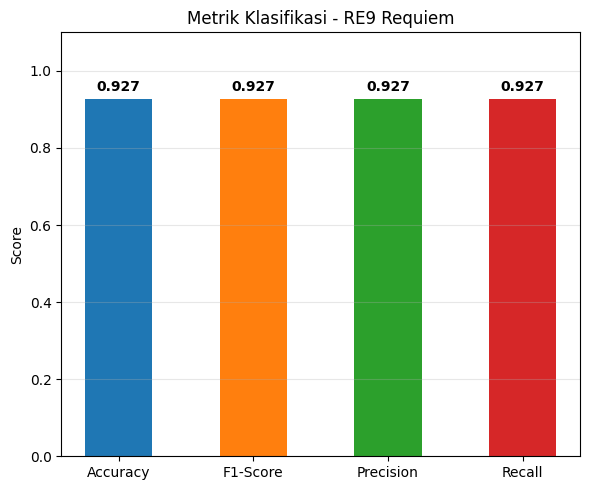

In [ ]:
# Data hasil prediksi
df_test_lengkap = pd.DataFrame({
    'review'  : x_test,
    'label'   : y_test,
    'pred'    : y_pred,
    'game'    : game_test,
    'prob_pos': proba[:, 1],
})

df_test_lengkap['benar'] = (
    df_test_lengkap['label'] ==
    df_test_lengkap['pred']
)

# --------------------------------------------------
# Filter hanya game RE9 Requiem
# --------------------------------------------------
df_re9 = df_test_lengkap[df_test_lengkap['game'] == 'RE9 Requiem']

# --------------------------------------------------
# Akurasi RE9 Requiem
# --------------------------------------------------
print('📊 Akurasi RE9 Requiem')

acc = accuracy_score(df_re9['label'], df_re9['pred'])
f1  = f1_score(df_re9['label'], df_re9['pred'], average='weighted')

print(
    f'RE9 Requiem     | '
    f'Accuracy={acc:.3f} | '
    f'F1={f1:.3f} | '
    f'n={len(df_re9)}'
)

# --------------------------------------------------
# Hitung metrik
# --------------------------------------------------
metrik_re9 = pd.Series({
    'Accuracy' : accuracy_score(df_re9['label'], df_re9['pred']),
    'F1-Score' : f1_score(df_re9['label'], df_re9['pred'], average='weighted'),
    'Precision': precision_score(df_re9['label'], df_re9['pred'], average='weighted', zero_division=0),
    'Recall'   : recall_score(df_re9['label'], df_re9['pred'], average='weighted', zero_division=0)
})

# --------------------------------------------------
# Visualisasi
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6,5))

metrik_cols = [
    'Accuracy',
    'F1-Score',
    'Precision',
    'Recall'
]

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

ax.bar(
    metrik_cols,
    metrik_re9[metrik_cols],
    color=colors,
    width=0.5
)

# tampilkan nilai di atas bar
for i, v in enumerate(metrik_re9[metrik_cols]):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Metrik Klasifikasi - RE9 Requiem')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1997 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review         1997 non-null   object
 1   label          1997 non-null   int64 
 2   game           1997 non-null   object
 3   jenis          1997 non-null   object
 4   review_bersih  1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 93.6+ KB


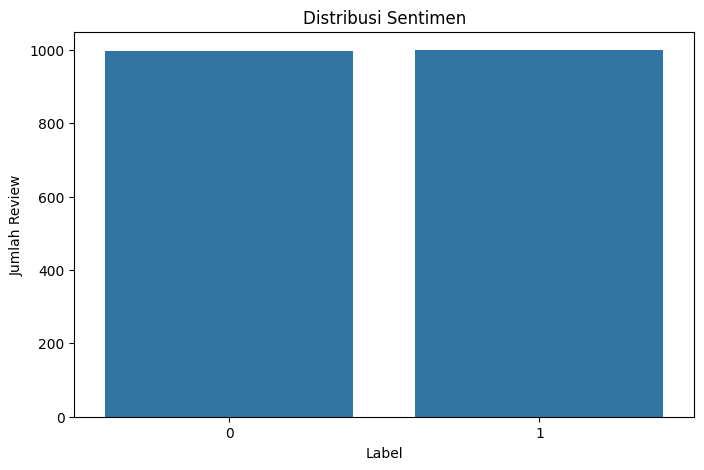

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='label'
)

plt.title('Distribusi Sentimen')
plt.xlabel('Label')
plt.ylabel('Jumlah Review')

plt.show()

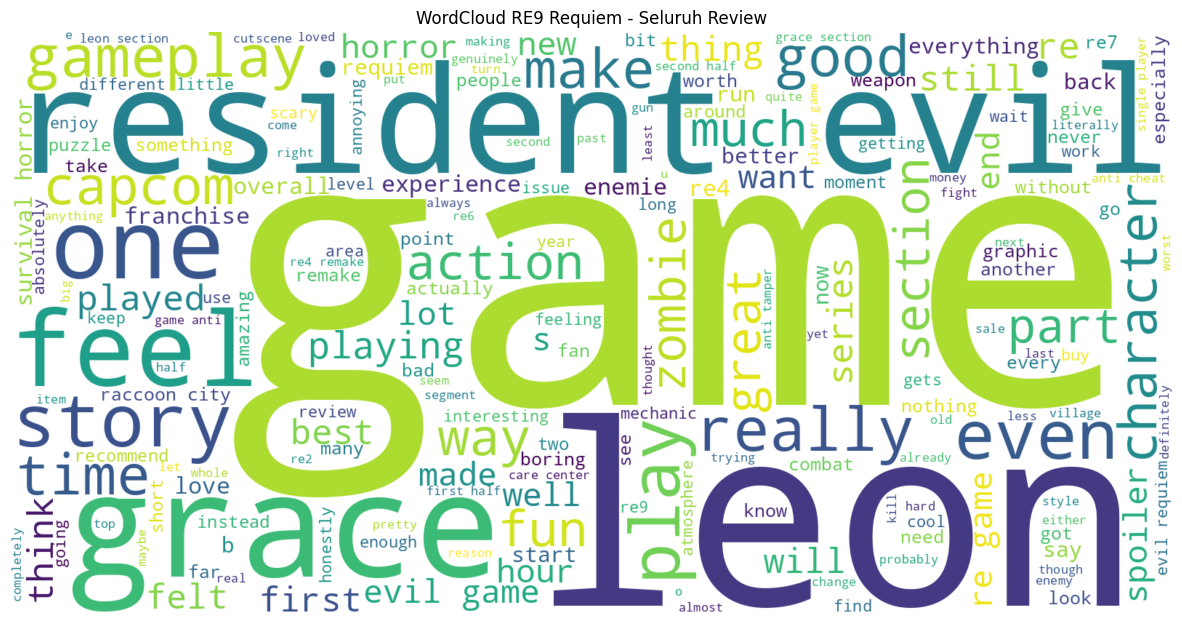

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['review_bersih'].astype(str))

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud RE9 Requiem - Seluruh Review')
plt.show()

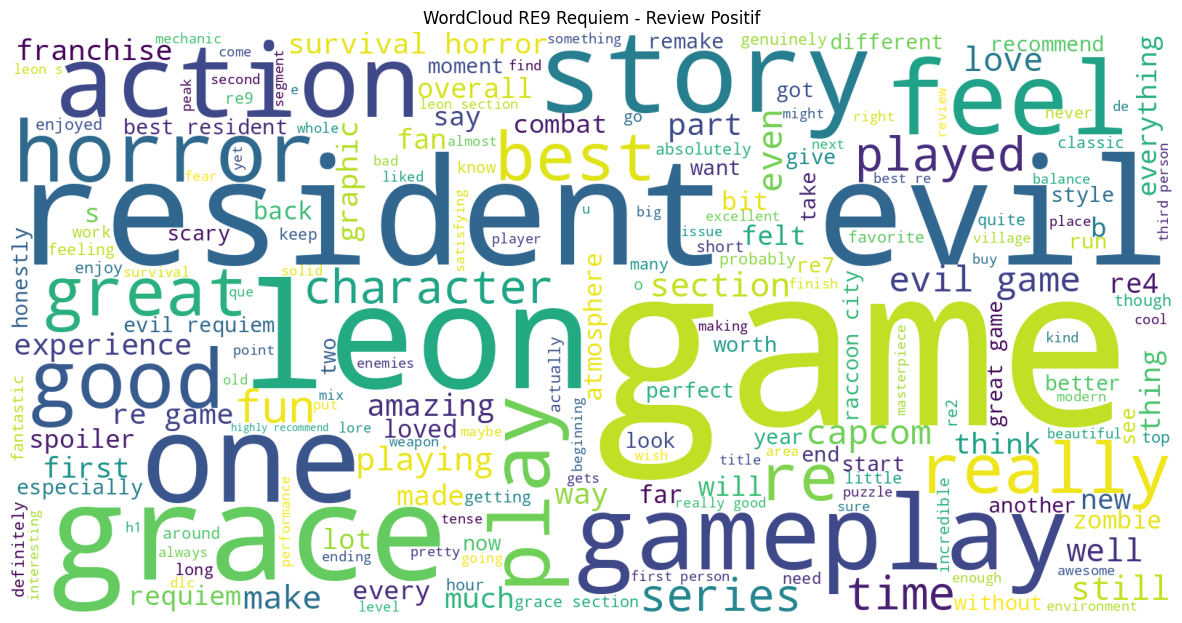

In [ ]:
positive_text = " ".join(
    df[df['label']==1]['review_bersih']
)

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud RE9 Requiem - Review Positif")
plt.show()

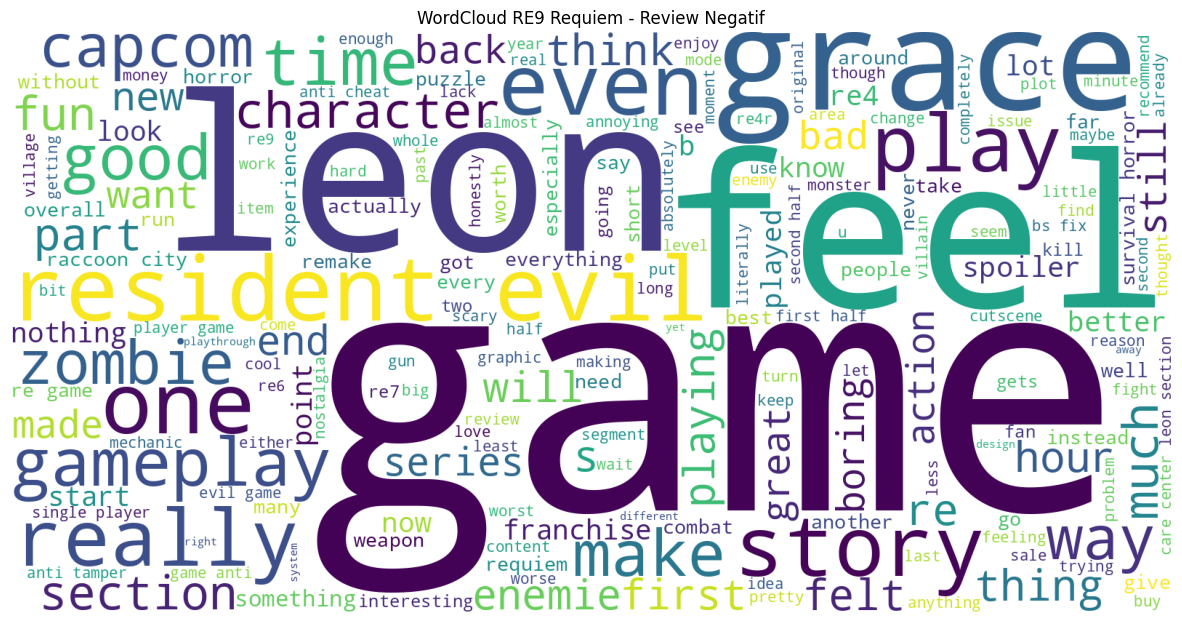

In [ ]:
negative_text = " ".join(
    df[df['label']==0]['review_bersih']
)

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud RE9 Requiem - Review Negatif")
plt.show()

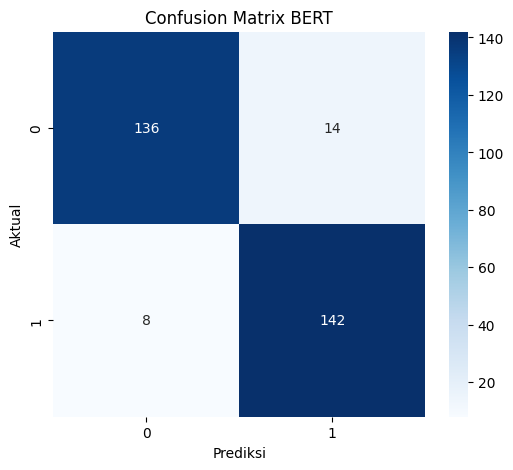

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix BERT")

plt.show()

Berdasarkan confusion matrix, model BERT berhasil mengklasifikasikan 136 review negatif dan 142 review positif dengan benar. Model melakukan kesalahan klasifikasi pada 14 review negatif yang diprediksi sebagai positif (False Positive) dan 8 review positif yang diprediksi sebagai negatif (False Negative). Dengan demikian, dari total 300 data uji, model berhasil mengklasifikasikan 278 data dengan benar dan memperoleh akurasi sebesar 92,67%. Hasil tersebut menunjukkan bahwa model BERT memiliki kemampuan klasifikasi sentimen yang baik dalam mengidentifikasi sentimen review game Capcom pada platform Steam.

In [ ]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

print(metrics)

{'Accuracy': 0.9266666666666666, 'Precision': 0.9102564102564102, 'Recall': 0.9466666666666667, 'F1-Score': 0.9281045751633987}


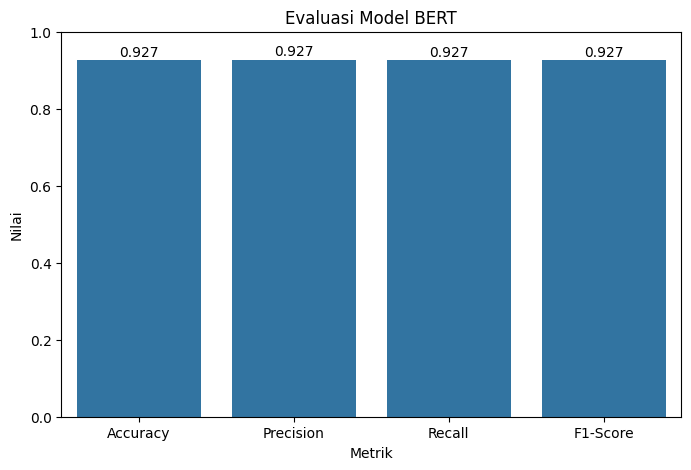

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted'),
    'Recall': recall_score(y_test, y_pred, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred, average='weighted')
}

metric_df = pd.DataFrame(
    metrics.items(),
    columns=['Metrik','Nilai']
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=metric_df,
    x='Metrik',
    y='Nilai'
)

plt.ylim(0,1)

for i,v in enumerate(metric_df['Nilai']):
    plt.text(i,v+0.01,f'{v:.3f}',ha='center')

plt.title('Evaluasi Model BERT')

plt.show()

Accuracy = 88,7%

Nilai accuracy sebesar 88,7% menunjukkan bahwa model BERT mampu mengklasifikasikan sentimen review Steam dengan tingkat ketepatan yang tinggi. Dari seluruh data uji, sekitar 89% review berhasil diprediksi dengan benar.

Precision = 91,4%

Nilai precision sebesar 91,4% menunjukkan bahwa sebagian besar review yang diprediksi positif oleh model memang benar-benar termasuk ke dalam kelas positif. Hal ini mengindikasikan tingkat kesalahan False Positive yang rendah.

Recall = 85,3%

Nilai recall sebesar 85,3% menunjukkan kemampuan model dalam menemukan review positif yang sebenarnya. Masih terdapat sejumlah review positif yang salah diklasifikasikan sebagai negatif.

F1-Score = 88,3%

Nilai F1-Score sebesar 88,3% menunjukkan keseimbangan yang baik antara precision dan recall, sehingga model dapat dianggap memiliki performa klasifikasi yang stabil.

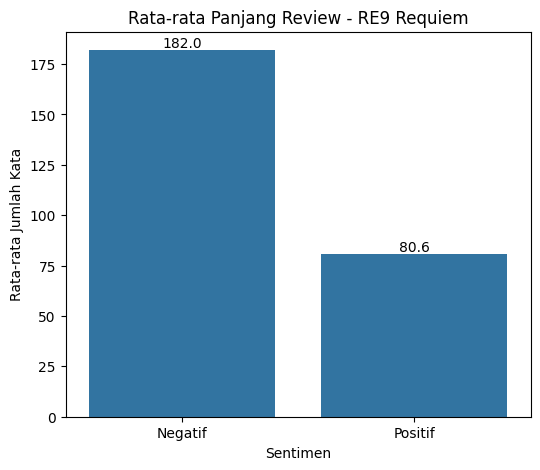

In [ ]:
# Hitung panjang review
df['panjang_review'] = df['review_bersih'].astype(str).apply(
    lambda x: len(x.split())
)

# Rata-rata panjang review per sentimen (RE9 Requiem)
avg_length = (
    df.groupby('label')['panjang_review']
      .mean()
      .reset_index()
)

avg_length['label'] = avg_length['label'].map({
    0: 'Negatif',
    1: 'Positif'
})

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=avg_length,
    x='label',
    y='panjang_review'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Rata-rata Panjang Review - RE9 Requiem')
plt.xlabel('Sentimen')
plt.ylabel('Rata-rata Jumlah Kata')
plt.show()

Review negatif pada RE9 Requiem memiliki rata-rata panjang yang lebih tinggi dibandingkan review positif. Hal ini mengindikasikan bahwa pengguna yang memberikan sentimen negatif cenderung menyampaikan kritik yang lebih mendalam dan detail dibandingkan pengguna yang memberikan apresiasi positif.

In [ ]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

custom_stopwords = set(stopwords.words('english'))

custom_stopwords.update([
    'game',
    'games',
    'play',
    'playing',
    'played',
    'like',
    'really',
    'one',
    'get',
    'got',
    'would',
    'also',
    'even',
    'much',
    'still',
    'make',
    'made',
    'good',
    'great',
    'best',
    'well',
    'time',
    'people',
    'player',
    'players'
])

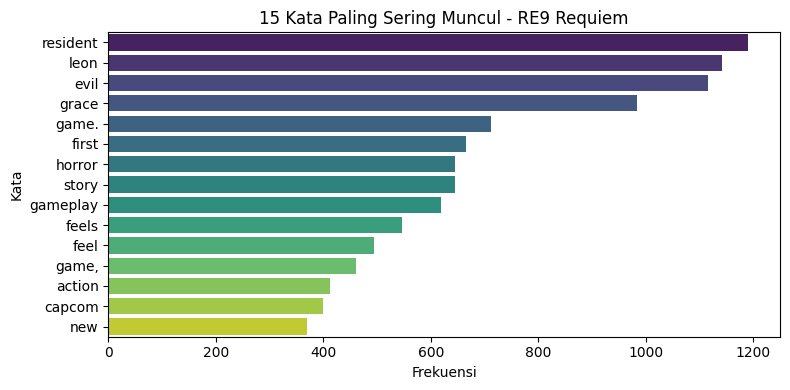

In [ ]:
from collections import Counter

text = " ".join(df['review_bersih'])

words = text.split()

filtered_words = [
    w for w in words
    if w.lower() not in custom_stopwords
    and len(w) > 2
]

counter = Counter(filtered_words)

top_df = pd.DataFrame(
    counter.most_common(15),
    columns=['Kata', 'Frekuensi']
)

plt.figure(figsize=(8,4))

sns.barplot(
    data=top_df,
    x='Frekuensi',
    y='Kata',
    palette='viridis'
)

plt.title('15 Kata Paling Sering Muncul - RE9 Requiem')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

Review RE9 Requiem didominasi oleh pembahasan karakter utama seperti Leon dan Grace, serta unsur horror yang menjadi ciri khas seri Resident Evil. Selain itu, aspek atmosfer, cerita, dan gameplay survival horror juga banyak disebutkan oleh para pemain dalam ulasan mereka.

In [ ]:
custom_reviews = [
    "TOO SHORT GAMEPLAY .... SO BAD... MORE THAN BETTER RE 4 REMAKE",
    "100 dollars for the game and you tits can't get the audio sync right during cutscenes. Bloody embarrassing, it's 10 seconds out of sync with me changing options everytime to fix it, but nothing fixees it. other RE games ive played had no issue, but the sound is something i cant deal with.  ive bought much cheaper games and had no issues with ANYTHING.  fix you â™¥â™¥â™¥â™¥!!!",
    "Game is amazing for what I have played of it!  Really feels like a mix of 4 & 7",
    "honestly best re ive played its very fun. very scary and the leon parts are really fun with all the mechanics. its story is nice with the beginning being fun and hard and scary",
    "Wonderful story line graphics are terrific even on medium which is what I played on. Couldn't recommend this game enough."
]

In [ ]:
# DATASET TANPA LABEL

dummy_label = [0] * len(custom_reviews)

custom_dataset = ReviewDataset(
    custom_reviews,
    dummy_label,
    tokenizer,
    max_length
)


# PREDIKSI

hasil = trainer.predict(custom_dataset)

logits = hasil.predictions

prediksi = np.argmax(logits, axis=1)


# UBAH KE TEKS

sentimen = [
    "Positif" if p == 1 else "Negatif"
    for p in prediksi
]


# DATAFRAME

hasil_custom = pd.DataFrame({
    "Review": custom_reviews,
    "Prediksi Model": prediksi,
    "Sentimen": sentimen
})

display(hasil_custom)

,Review,Prediksi Model,Sentimen
0,TOO SHORT GAMEPLAY .... SO BAD... MORE THAN BE...,0,Negatif
1,100 dollars for the game and you tits can't ge...,0,Negatif
2,Game is amazing for what I have played of it! ...,1,Positif
3,honestly best re ive played its very fun. very...,1,Positif
4,Wonderful story line graphics are terrific eve...,1,Positif


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r checkpoint_bert /content/drive/MyDrive/

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

path_checkpoint = '/content/drive/MyDrive/checkpoint_bert/checkpoint-273' # pakai checkpoint tertinggi

tokenizer = AutoTokenizer.from_pretrained(path_checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(path_checkpoint)